# C/N/O line cooling: CHIANTI data vs new fits vs current AIOLOS formulas

The C I, C II, O I, O II coolants in `Cool_coeff.f90` are AIOLOS analytic
fits (ported from `photochem.cpp`, no in-code citation, likely
Cloudy-calibrated); N I/N II have **no** line cooling in that scheme.
This notebook compares them against the CHIANTI v11.0.2 optically-thin
cooling curves and against the new closed-form fits

$$\Lambda(T) = T^{-1/2}\sum_i A_i\,e^{-T_i/T}
\qquad[\mathrm{erg\,cm^3\,s^{-1}}\ \text{per }(n_e\,n_{\rm ion})]$$

(same effective two-level form as the Fe II coronal fit; coefficients from
`fit_cno_formulas.py`).  Lower levels are Boltzmann-populated over the
ground-term fine structure (C I $^3$P, C II $^2$P, N II $^3$P, O I $^3$P);
the $^4$S$_{3/2}$ ground of N I and O II is a single level.

**Runtime selection** (`metals.inp`): `cno_cool 0` (default) = AIOLOS fits,
`cno_cool 1` = the CHIANTI fits below (including N I/N II).

**Caveat** (applies to both schemes): the fine-structure floor terms
([C II] 158 $\mu$m, [O I] 63 $\mu$m; $T_i\lesssim10^3$ K) have low critical
densities ($n_e\sim10$–$10^5$ cm$^{-3}$) and saturate at the dense
atmosphere base; the coronal curves overestimate that contribution there.
`use_2lev_cool` treats the saturation explicitly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from chianti_cooling import cooling_effective

T = np.logspace(3.0, 5.0, 201)
IONS = ['CI', 'CII', 'NI', 'NII', 'OI', 'OII']
CHIANTI_SPEC = {'CI': ('c', 1), 'CII': ('c', 2), 'NI': ('n', 1),
                'NII': ('n', 2), 'OI': ('o', 1), 'OII': ('o', 2)}
LABELS = {'CI': r'C I', 'CII': r'C II', 'NI': r'N I',
          'NII': r'N II', 'OI': r'O I', 'OII': r'O II'}

chianti = {nm: cooling_effective(el, st, T, pop='ground_term')
           for nm, (el, st) in CHIANTI_SPEC.items()}

In [2]:
# --- current AIOLOS formulas (Cool_coeff.f90 default mode) ---
def aiolos(name, T):
    if name == 'CI':
        return 1.0e-24 + 3.1e-20*np.exp(-15162.0/T)*(1.0 + (T/2.0e4)**1.5)
    if name == 'CII':
        return 1.5e-23 + 3.1e-20*np.exp(-45162.0/T)*(1.0 + (T/0.75e4)**1.5)
    if name == 'OI':
        return 5.5e-24 + 1.1e-20*np.exp(-30162.0/T)*(1.0 + (T/0.75e4)**0.5)
    if name == 'OII':
        return 5.1e-20*np.exp(-35162.0/T)*(1.0 + (T/0.75e4)**0.5)
    return np.zeros_like(T)   # N I, N II: no cooling in AIOLOS scheme

# --- new CHIANTI fits (Cool_coeff.f90 cno_cool=1; fit_cno_formulas.py) ---
COEF = {
 'CI':  ([1.10625037e-20, 1.39158295e-18, 6.96187591e-18, 6.59348477e-17,
          3.01715156e-16],
         [2351.38, 15172.3, 25411.0, 72609.1, 177264.0]),
 'CII': ([3.00421499e-20, 2.41049257e-20, 3.90434784e-17, 3.33191635e-16,
          1.36009298e-15],
         [61.3684, 7183.05, 64103.6, 124809.0, 246136.0]),
 'NI':  ([1.51401524e-18, 4.87732307e-18, 1.15970782e-17, 1.57486268e-16,
          3.17477537e-16],
         [29686.2, 34693.8, 50740.7, 139916.0, 254192.0]),
 'NII': ([2.40595483e-20, 1.24400479e-20, 8.04015794e-18, 1.54493674e-17,
          2.88420949e-16, 6.94381304e-16],
         [49.914, 6521.42, 23770.8, 64487.2, 157103.0, 295894.0]),
 'OI':  ([3.23621357e-22, 6.57165017e-20, 1.80264414e-18, 6.76183709e-18,
          3.37196426e-17],
         [847.937, 19058.9, 31568.4, 70528.3, 178827.0]),
 'OII': ([1.76816973e-17, 8.07102200e-18, 2.34447515e-16, 8.78914372e-16],
         [44128.6, 59732.3, 179091.0, 325669.0]),
}

def newfit(name, T):
    A, Ti = np.asarray(COEF[name][0]), np.asarray(COEF[name][1])
    return np.sum(A[:, None]*np.exp(-Ti[:, None]/T[None, :]),
                  axis=0)/np.sqrt(T)

for nm in IONS:
    rel = np.abs(newfit(nm, T)/chianti[nm] - 1.0)
    mask = chianti[nm] > 1e-3*chianti[nm].max()
    av = aiolos(nm, T)
    if av.max() > 0:
        arel = np.abs(av/chianti[nm] - 1.0)[mask]
        astr = f'AIOLOS max dev {arel.max()*100:6.1f}%'
    else:
        astr = 'AIOLOS: no cooling'
    print(f'{nm:4s}  new-fit max err {rel.max()*100:5.2f}%   {astr}')

CI    new-fit max err  1.82%   AIOLOS max dev   21.1%
CII   new-fit max err  0.47%   AIOLOS max dev   98.3%
NI    new-fit max err  0.59%   AIOLOS: no cooling
NII   new-fit max err  0.14%   AIOLOS: no cooling
OI    new-fit max err  2.11%   AIOLOS max dev   52.6%
OII   new-fit max err  0.23%   AIOLOS max dev   69.2%


## Per-ion comparison

Blue = CHIANTI v11 data, black dashed = new closed-form fit, red dotted = current AIOLOS formula (absent for N).
Bottom strips: relative deviation from CHIANTI ($\pm$5% band shaded); note the AIOLOS curves can leave the strip range.

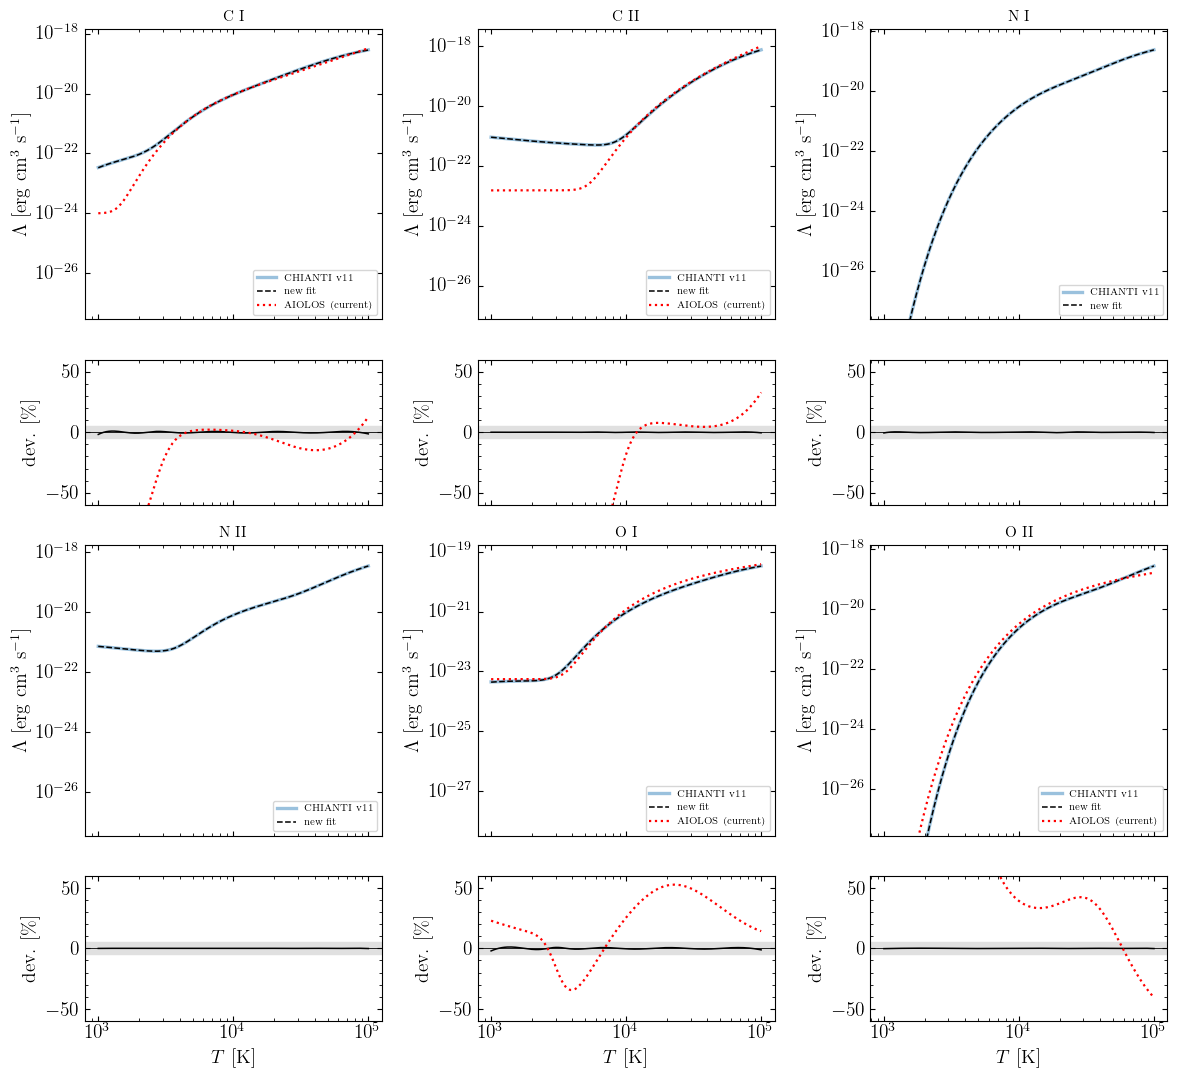

In [3]:
fig, axes = plt.subplots(4, 3, figsize=(12, 11), sharex=True,
                         gridspec_kw=dict(height_ratios=[2, 1, 2, 1]))
pos = [(0, 0), (0, 1), (0, 2), (2, 0), (2, 1), (2, 2)]
for k, nm in enumerate(IONS):
    r, c = pos[k]
    axc, axr = axes[r, c], axes[r + 1, c]
    dat, fit, av = chianti[nm], newfit(nm, T), aiolos(nm, T)
    axc.plot(T, dat, lw=2.4, alpha=0.45, label='CHIANTI v11')
    axc.plot(T, fit, 'k--', lw=1.1, label='new fit')
    if av.max() > 0:
        axc.plot(T, av, 'r:', lw=1.6, label='AIOLOS (current)')
    axc.set_xscale('log'); axc.set_yscale('log')
    axc.set_ylim(dat.max()*1e-9, dat.max()*5)
    axc.set_title(LABELS[nm], fontsize=11)
    axc.set_ylabel(r'$\Lambda$ [erg cm$^3$ s$^{-1}$]')
    axc.legend(fontsize=7, loc='lower right')
    axr.axhspan(-5, 5, color='0.88')
    axr.axhline(0, color='k', lw=0.6)
    axr.plot(T, (fit/dat - 1.0)*100, 'k-', lw=1.1)
    if av.max() > 0:
        axr.plot(T, (av/dat - 1.0)*100, 'r:', lw=1.6)
    axr.set_ylim(-60, 60)
    axr.set_ylabel(r'dev. [\%]')
    if r == 2:
        axr.set_xlabel(r'$T$ [K]')
plt.tight_layout(); plt.show()

## Total C/N/O cooling at solar abundance ratios

Weight each ion curve by its solar element abundance (Asplund+2009; neutral-stage curve as proxy for the element) to gauge the aggregate impact of switching `cno_cool`. The N curves (absent in the AIOLOS scheme) peak near $2\times10^4$ K where the wind is launched.

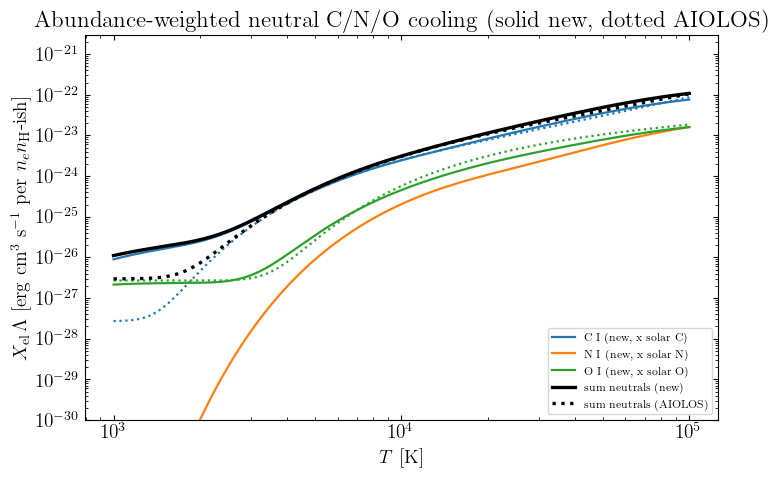

In [4]:
AB = {'C': 2.69e-4, 'N': 6.76e-5, 'O': 4.90e-4}
fig, ax = plt.subplots(figsize=(7.5, 5))
tot_new = np.zeros_like(T); tot_old = np.zeros_like(T)
for el, nI, nII in [('C', 'CI', 'CII'), ('N', 'NI', 'NII'),
                    ('O', 'OI', 'OII')]:
    ln, = ax.plot(T, AB[el]*newfit(nI, T), lw=1.6,
                  label=f'{el} I (new, x solar {el})')
    ax.plot(T, AB[el]*aiolos(nI, T), ':', lw=1.6, color=ln.get_color())
    tot_new += AB[el]*newfit(nI, T); tot_old += AB[el]*aiolos(nI, T)
ax.plot(T, tot_new, 'k-', lw=2.4, label='sum neutrals (new)')
ax.plot(T, tot_old, 'k:', lw=2.4, label='sum neutrals (AIOLOS)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_ylim(1e-30, 3e-21)
ax.set_xlabel(r'$T$ [K]')
ax.set_ylabel(r'$X_{\rm el}\,\Lambda$ [erg cm$^3$ s$^{-1}$ per $n_e n_{\rm H}$-ish]')
ax.set_title('Abundance-weighted neutral C/N/O cooling (solid new, dotted AIOLOS)')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

## Density-dependent fine-structure saturation ([C II] 158 $\mu$m, [O I] 63 $\mu$m)

The coronal curves above include the ground-term fine-structure floor
*unsaturated*; its critical density ($n_{\rm crit,e}\sim20$ cm$^{-3}$ for
[C II] 158 $\mu$m, $n_{\rm crit,H}\sim4\times10^5$ cm$^{-3}$ for
[O I] 63 $\mu$m) is far below the atmosphere base density. In the code
(`cno_cool 1`, default) the floor is therefore replaced by the exact
two-level solution

$$W_{\rm FS} = f_l(T)\,\frac{h\nu\,A\,x\,C_{\rm dex}}{A + C_{\rm dex}(1+x)},
\qquad x = \frac{g_u}{g_l}e^{-E/kT},\qquad
C_{\rm dex} = n_e k_e(T) + n_{\rm HI} k_{\rm H}(T)$$

with $f_l = g_l/Z_{\rm term}(T)$ (this weighting makes the two-level LTE
limit equal the exact ground-term Boltzmann population), $k_e$ from the
CHIANTI $\Upsilon$, and $k_{\rm H}$ from Yan \& Babb (2023; C I, N II),
Abrahamsson, Krems \& Dalgarno (2007; O I) and Barinovs et al. (2005; C II).
The non-FS remainder stays coronal (multi-exp refit excluding the
$1\!\to\!2$ channel; `fit_fs_saturation.py`).  Note the $n_{\rm HI}$
channel can also *raise* the cooling above the electron-only coronal
curve in mostly-neutral gas (the CHIANTI curve has no H collisions).

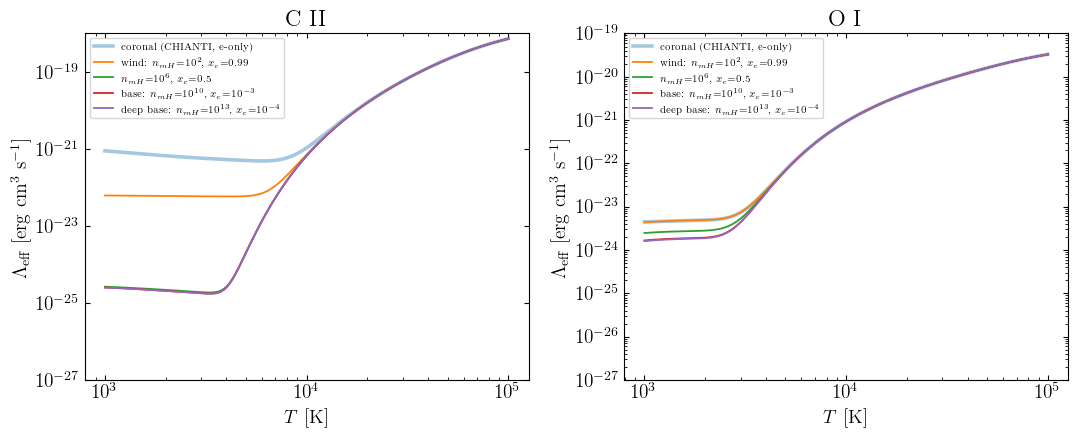

In [5]:
KB_CODE = 1.38e-16   # code-wide kb_erg (rounded, matches Cool_coeff.f90)

def w_fs_cii(T, ne, nHI):
    xl = np.log10(T/1e4)
    ups = 10**(0.33433316 + 0.11618314*xl - 0.087925806*xl**2
               - 0.061804561*xl**3)
    ke = 8.629e-6*ups/(4*np.sqrt(T))
    Cdex = ne*ke + nHI*4.0e-11
    x = 2*np.exp(-91.213/T)
    f1 = 2/(2 + 4*np.exp(-91.213/T))
    return f1*KB_CODE*91.213*2.290e-6*x*Cdex/(2.290e-6 + Cdex*(1 + x))

def cii_sat(T, ne, nHI):
    rem = (1.06878629e-23*np.exp(-294.754/T)
           + 3.04162479e-17*np.exp(-61740.4/T)
           + 2.30421959e-16*np.exp(-112006/T)
           + 1.29701808e-15*np.exp(-223343/T))/np.sqrt(T)
    return w_fs_cii(T, ne, nHI)/np.maximum(ne, 1e-30) + rem

def w_fs_oi(T, ne, nHI):
    xl = np.log10(T/1e4)
    ups = 10**(-2.0890112 + 0.19632883*xl - 0.16253745*xl**2
               + 0.041658804*xl**3)
    ke = 8.629e-6*ups/(3*np.sqrt(T))
    Cdex = ne*ke + nHI*4.2e-11*(T/100)**0.67
    x = 0.6*np.exp(-227.708/T)
    f1 = 5/(5 + 3*np.exp(-227.708/T) + np.exp(-326.567/T))
    return f1*KB_CODE*227.708*8.542e-5*x*Cdex/(8.542e-5 + Cdex*(1 + x))

def oi_sat(T, ne, nHI):
    rem = (1.29166532e-22*np.exp(-930.111/T)
           + 2.54689509e-19*np.exp(-22878.3/T)
           + 1.91904760e-18*np.exp(-34189.1/T)
           + 7.47798840e-18*np.exp(-75919.8/T)
           + 3.40871685e-17*np.exp(-185985/T))/np.sqrt(T)
    return w_fs_oi(T, ne, nHI)/np.maximum(ne, 1e-30) + rem

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
CASES = [(1e2, 0.99, 'wind: $n_{\rm H}{=}10^2$, $x_e{=}0.99$'),
         (1e6, 0.5, '$n_{\rm H}{=}10^6$, $x_e{=}0.5$'),
         (1e10, 1e-3, 'base: $n_{\rm H}{=}10^{10}$, $x_e{=}10^{-3}$'),
         (1e13, 1e-4, 'deep base: $n_{\rm H}{=}10^{13}$, $x_e{=}10^{-4}$')]
for ax, nm, fsat, lam0 in [(axes[0], 'C II', cii_sat, chianti['CII']),
                           (axes[1], 'O I', oi_sat, chianti['OI'])]:
    ax.plot(T, lam0, lw=2.6, alpha=0.4, label='coronal (CHIANTI, e-only)')
    for nH, xe, lab in CASES:
        ax.plot(T, fsat(T, nH*xe, nH*(1 - xe)), lw=1.3, label=lab)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$T$ [K]')
    ax.set_ylabel(r'$\Lambda_{\rm eff}$ [erg cm$^3$ s$^{-1}$]')
    ax.set_title(nm); ax.legend(fontsize=7, loc='upper left')
axes[0].set_ylim(1e-27, 1e-18); axes[1].set_ylim(1e-27, 1e-19)
plt.tight_layout(); plt.show()